In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

california = fetch_california_housing(as_frame=True)
df = california.frame

print(f"Dataset loaded successfully!")
print(f"Matrix Shape: {df.shape[0]} rows by {df.shape[1]} columns.\n")
df.head()

Dataset loaded successfully!
Matrix Shape: 20640 rows by 9 columns.



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


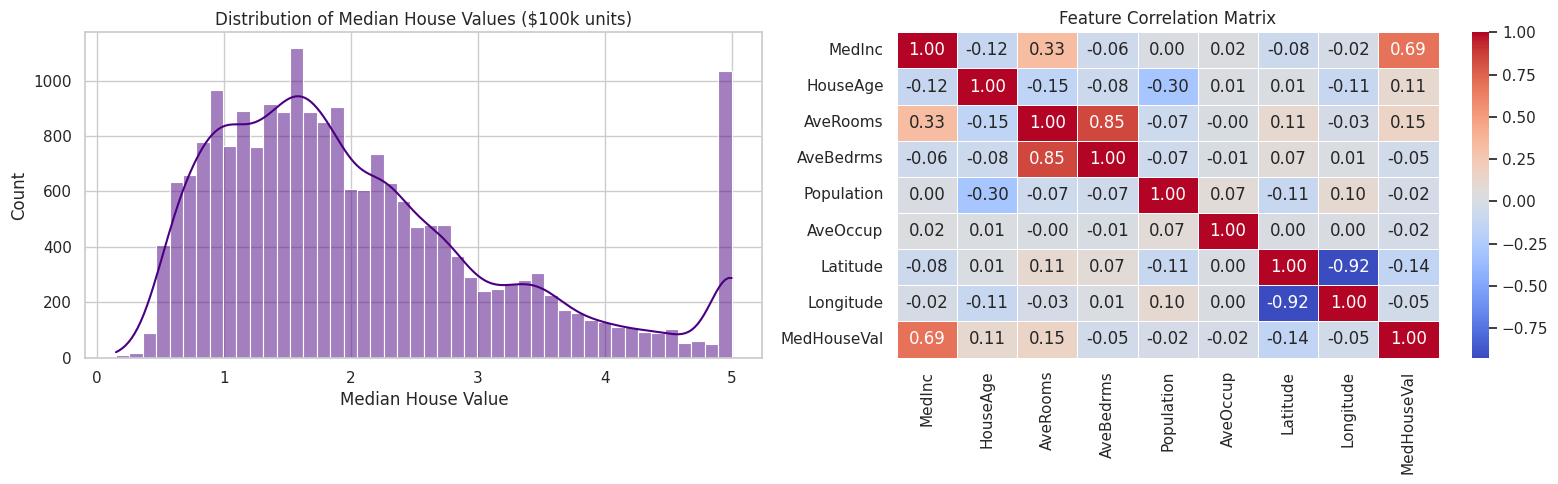

In [2]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['MedHouseVal'], kde=True, ax=axes[0], color='indigo')
axes[0].set_title('Distribution of Median House Values ($100k units)')
axes[0].set_xlabel('Median House Value')

corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1])
axes[1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

In [4]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data processing complete!")
print(f"Training Subset: {X_train_scaled.shape[0]} samples")
print(f"Testing Subset: {X_test_scaled.shape[0]} samples")

Data processing complete!
Training Subset: 16512 samples
Testing Subset: 4128 samples


In [5]:
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Training Linear Regression baseline...")
lr_model.fit(X_train_scaled, y_train)

print("Training Random Forest ensemble...")
rf_model.fit(X_train_scaled, y_train)

print("Both models successfully trained!")

Training Linear Regression baseline...
Training Random Forest ensemble...
Both models successfully trained!


=== Linear Regression Baseline Performance ===
Mean Absolute Error (MAE)    : 0.5332
Root Mean Squared Error (RMSE): 0.7456
R-squared Score (R²)         : 0.5758

=== Random Forest Regressor Performance ===
Mean Absolute Error (MAE)    : 0.3274
Root Mean Squared Error (RMSE): 0.5051
R-squared Score (R²)         : 0.8053



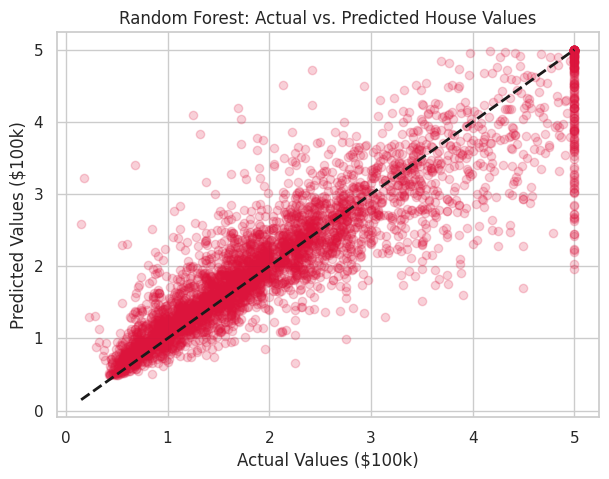

In [6]:
lr_pred = lr_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test_scaled)

def evaluate_regression_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"=== {model_name} Performance ===")
    print(f"Mean Absolute Error (MAE)    : {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared Score (R²)         : {r2:.4f}\n")

evaluate_regression_model(y_test, lr_pred, "Linear Regression Baseline")
evaluate_regression_model(y_test, rf_pred, "Random Forest Regressor")

plt.figure(figsize=(7, 5))
plt.scatter(y_test, rf_pred, alpha=0.2, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Random Forest: Actual vs. Predicted House Values')
plt.xlabel('Actual Values ($100k)')
plt.ylabel('Predicted Values ($100k)')
plt.show()

In [7]:
model_out = 'house_price_random_forest_model.pkl'
scaler_out = 'house_price_scaler.pkl'

joblib.dump(rf_model, model_out)
joblib.dump(scaler, scaler_out)

print(f"Successfully exported artifacts:\n➔ {model_out}\n➔ {scaler_out}")

Successfully exported artifacts:
➔ house_price_random_forest_model.pkl
➔ house_price_scaler.pkl
